# Alpamayo 2 — 公式実装と同じ数式で動かす最小再実装

> NVIDIA の自動運転 VLA モデル [Alpamayo 2 Super](https://github.com/NVlabs/alpamayo2) の中核部分を、
> 公式実装 (`NVlabs/alpamayo2`) の数式・ハイパーパラメータをそのまま使って CPU 上に再構築する。
> 理論の詳細は companion report [alpamayo2.md](alpamayo2.md) を参照。

本 notebook で「本物」なのは以下である。

- `UnicycleAccelCurvatureActionSpace.action_to_traj` の積分式（台形則、cumsum 実装）
- 低速時の曲率クランプ `_LOW_SPEED_CURVATURE_THRESHOLD_MPS = 0.6`
- `FlowMatching` の学習データ構成 `t*x + (1-t)*noise`、損失ターゲット `x - noise`、Euler サンプラ
- `train_timestep_sampler="beta"` の `Beta(1.5, 1.0)` 反転サンプリング
- `FourierEncoderV2` / `PerWaypointActionInProjV2` の射影
- 公式 `config.json` の実数値（`n_waypoints=64`, `dt=0.1`, `accel_std=0.6810426736454882` 等）
- Chain-of-Causation の閉集合 driving decision 語彙

「代用」なのは VLM バックボーンのみ（32B の Cosmos 3 Super Reasoner → 小さな Transformer）と、
入力画像（実車載映像 → 合成マルチカメラシーン）である。
実 VLM を使った版は [alpamayo2_gpu_smoke_kaggle.ipynb](alpamayo2_gpu_smoke_kaggle.ipynb)（Kaggle T4）にある。


In [1]:
import math

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
torch.set_num_threads(4)

print("torch:", torch.__version__)
print("device: cpu (this notebook is CPU-only by design)")


torch: 2.12.0+cu130
device: cpu (this notebook is CPU-only by design)


## 1. 公式 config の実数値をそのまま定数にする

`nvidia/Alpamayo2-Super` の `config.json` から抜き出した値をそのまま使う。
再実装で最も間違えやすいのは正規化統計で、これが違うと action の分布がずれて学習が壊れる。


In [2]:
# nvidia/Alpamayo2-Super : config.json (action_space_cfg / diffusion_cfg) の実数値
N_WAYPOINTS = 64          # 予測 waypoint 数
DT = 0.1                  # 刻み [s] -> 64 * 0.1 = 6.4 秒先まで
ACCEL_BOUNDS = (-9.8, 9.8)
CURVATURE_BOUNDS = (-0.33, 0.33)

ACCEL_MEAN = 0.02902694707164455
ACCEL_STD = 0.6810426736454882
CURVATURE_MEAN = 0.0002692167976330542
CURVATURE_STD = 0.026148280660833106

NUM_INFERENCE_STEPS = 10  # FlowMatching のデフォルト Euler ステップ数
LOW_SPEED_CURVATURE_THRESHOLD_MPS = 0.6  # unicycle_accel_curvature.py の定数

print(f"horizon      : {N_WAYPOINTS} waypoints x {DT}s = {N_WAYPOINTS * DT}s")
print(f"accel  norm  : mean={ACCEL_MEAN:.6f} std={ACCEL_STD:.6f} bounds={ACCEL_BOUNDS}")
print(f"kappa  norm  : mean={CURVATURE_MEAN:.6f} std={CURVATURE_STD:.6f} bounds={CURVATURE_BOUNDS}")
print(f"diffusion    : euler, {NUM_INFERENCE_STEPS} steps")

# 正規化統計の意味: 正規化後の action=+1 が実世界で何 m/s^2 / 1/m にあたるか
print()
print(f"normalized accel +1.0 -> {ACCEL_MEAN + ACCEL_STD:.3f} m/s^2")
print(f"normalized kappa +1.0 -> {CURVATURE_MEAN + CURVATURE_STD:.5f} 1/m "
      f"(= turn radius {1.0 / (CURVATURE_MEAN + CURVATURE_STD):.1f} m)")


horizon      : 64 waypoints x 0.1s = 6.4s
accel  norm  : mean=0.029027 std=0.681043 bounds=(-9.8, 9.8)
kappa  norm  : mean=0.000269 std=0.026148 bounds=(-0.33, 0.33)
diffusion    : euler, 10 steps

normalized accel +1.0 -> 0.710 m/s^2
normalized kappa +1.0 -> 0.02642 1/m (= turn radius 37.9 m)


## 2. Action space — unicycle 運動学で action を trajectory に積分する

Alpamayo は waypoint を直接回帰せず、**加速度 $a^i$ と曲率 $\kappa^i$ の系列**を予測して積分する。
論文 Eq.5 の Euler 離散化（位置更新は台形則）:

$$\mathbf{x}^{i+1}=\begin{pmatrix}x^{i+1}\\y^{i+1}\\\theta^{i+1}\\v^{i+1}\end{pmatrix}=\begin{pmatrix}x^{i}+\frac{\Delta T}{2}\left(v^{i}\cos\theta^{i}+v^{i+1}\cos\theta^{i+1}\right)\\ y^{i}+\frac{\Delta T}{2}\left(v^{i}\sin\theta^{i}+v^{i+1}\sin\theta^{i+1}\right)\\ \theta^{i}+\Delta T\,\kappa^{i}v^{i}+\frac{\Delta T^{2}}{2}\kappa^{i}a^{i}\\ v^{i}+\Delta T\,a^{i}\end{pmatrix}$$

以下は公式実装 `action_to_traj` の cumsum 版をそのまま移植したものである
(`src/alpamayo2_super/action_space/unicycle_accel_curvature.py`)。


In [3]:
class UnicycleAccelCurvatureActionSpace(nn.Module):
    """NVlabs/alpamayo2 の UnicycleAccelCurvatureActionSpace の移植 (action->traj 部分)."""

    def __init__(self, accel_mean=ACCEL_MEAN, accel_std=ACCEL_STD,
                 curvature_mean=CURVATURE_MEAN, curvature_std=CURVATURE_STD,
                 accel_bounds=ACCEL_BOUNDS, curvature_bounds=CURVATURE_BOUNDS,
                 dt=DT, n_waypoints=N_WAYPOINTS):
        super().__init__()
        self.register_buffer("accel_mean", torch.tensor(accel_mean))
        self.register_buffer("accel_std", torch.tensor(accel_std))
        self.register_buffer("curvature_mean", torch.tensor(curvature_mean))
        self.register_buffer("curvature_std", torch.tensor(curvature_std))
        self.accel_bounds = accel_bounds
        self.curvature_bounds = curvature_bounds
        self.dt = dt
        self.n_waypoints = n_waypoints

    def get_action_space_dims(self):
        return (self.n_waypoints, 2)

    def is_within_bounds(self, action):
        """正規化された action が物理境界の中に収まっているか (..., N, 2) -> (...,)."""
        accel = action[..., 0] * self.accel_std + self.accel_mean
        kappa = action[..., 1] * self.curvature_std + self.curvature_mean
        ok_a = (accel >= self.accel_bounds[0]) & (accel <= self.accel_bounds[1])
        ok_k = (kappa >= self.curvature_bounds[0]) & (kappa <= self.curvature_bounds[1])
        return torch.all(ok_a & ok_k, dim=-1)

    def action_to_traj(self, action, v0):
        """正規化 action (..., N, 2) と初速 v0 (...,) から (..., N, 2) の xy 軌道を作る."""
        accel, kappa = action[..., 0], action[..., 1]
        accel = accel * self.accel_std + self.accel_mean
        kappa = kappa * self.curvature_std + self.curvature_mean

        dt = self.dt
        dt_2_term = 0.5 * (dt ** 2)

        # v^{i+1} = v^i + dt * a^i  を cumsum で一括計算 -> (..., N+1)
        velocity = torch.cat([v0.unsqueeze(-1),
                              v0.unsqueeze(-1) + torch.cumsum(accel * dt, dim=-1)], dim=-1)

        # theta^{i+1} = theta^i + dt*kappa*v + dt^2/2*kappa*a -> (..., N+1)
        initial_yaw = torch.zeros_like(v0)
        theta = torch.cat([
            initial_yaw.unsqueeze(-1),
            initial_yaw.unsqueeze(-1)
            + torch.cumsum(kappa * velocity[..., :-1] * dt, dim=-1)
            + torch.cumsum(kappa * accel * dt_2_term, dim=-1),
        ], dim=-1)

        # 位置は台形則: 0.5*dt*(v^i cos th^i) + 0.5*dt*(v^{i+1} cos th^{i+1}) の 2 本の cumsum
        half_dt = 0.5 * dt
        x = (torch.cumsum(velocity[..., :-1] * torch.cos(theta[..., :-1]) * half_dt, dim=-1)
             + torch.cumsum(velocity[..., 1:] * torch.cos(theta[..., 1:]) * half_dt, dim=-1))
        y = (torch.cumsum(velocity[..., :-1] * torch.sin(theta[..., :-1]) * half_dt, dim=-1)
             + torch.cumsum(velocity[..., 1:] * torch.sin(theta[..., 1:]) * half_dt, dim=-1))
        return torch.stack([x, y], dim=-1), velocity, theta


action_space = UnicycleAccelCurvatureActionSpace()
print("action space dims:", action_space.get_action_space_dims())

# サニティチェック: accel=0, kappa=0 (=正規化前が 0) なら等速直進のはず
raw_zero = torch.zeros(1, N_WAYPOINTS, 2)
norm_zero = raw_zero.clone()
norm_zero[..., 0] = (0.0 - ACCEL_MEAN) / ACCEL_STD
norm_zero[..., 1] = (0.0 - CURVATURE_MEAN) / CURVATURE_STD
v0 = torch.tensor([10.0])
traj, vel, th = action_space.action_to_traj(norm_zero, v0)
print(f"\n等速直進チェック (v0=10 m/s, a=0, kappa=0):")
print(f"  6.4s 後の x = {traj[0, -1, 0]:.4f} m  (理論値 10.0 * 6.4 = 64.0 m)")
print(f"  6.4s 後の y = {traj[0, -1, 1]:.6f} m  (理論値 0.0 m)")
assert abs(traj[0, -1, 0].item() - 64.0) < 1e-3, "直進距離が理論値と合わない"
assert abs(traj[0, -1, 1].item()) < 1e-6, "横方向にずれている"
print("  OK")


action space dims: (64, 2)

等速直進チェック (v0=10 m/s, a=0, kappa=0):
  6.4s 後の x = 64.0000 m  (理論値 10.0 * 6.4 = 64.0 m)
  6.4s 後の y = 0.000000 m  (理論値 0.0 m)
  OK


### 2.1 代表的な運転行動を action 空間で書いて可視化する

CoC の driving decision 語彙に対応する 4 つの挙動を、加速度・曲率のプロファイルとして直接書き下し、
上の積分器に通す。**trajectory を直接描くのではなく制御量から生成している**点が Alpamayo の設計そのものである。


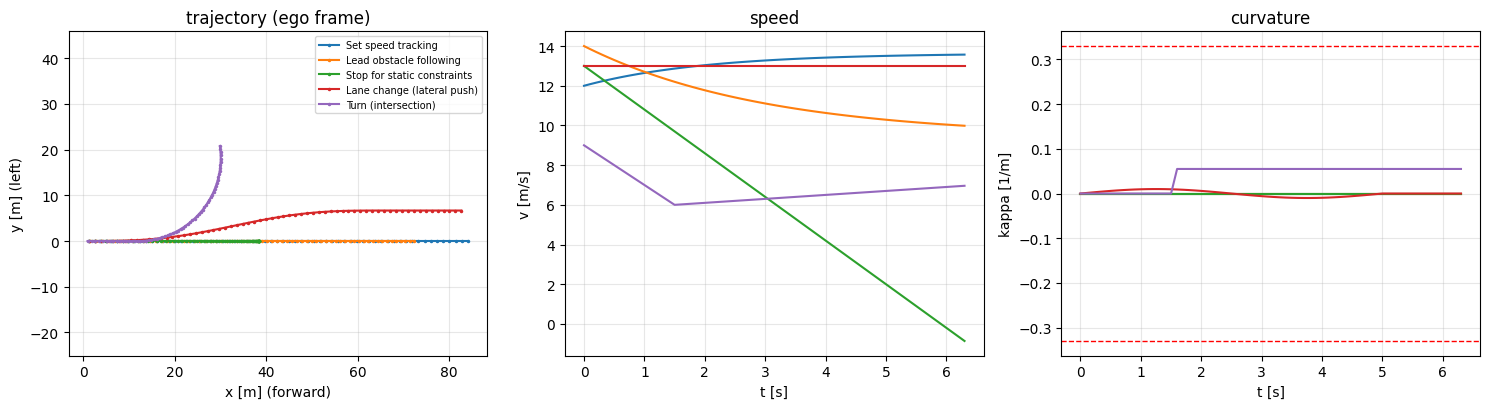

Set speed tracking               6.4s後 x=  84.15m y=   0.00m 終速=13.57m/s bounds_ok=True
Lead obstacle following          6.4s後 x=  72.42m y=   0.00m 終速= 9.97m/s bounds_ok=True
Stop for static constraints      6.4s後 x=  38.14m y=   0.00m 終速=-1.08m/s bounds_ok=True
Lane change (lateral push)       6.4s後 x=  82.68m y=   6.69m 終速=13.00m/s bounds_ok=True
Turn (intersection)              6.4s後 x=  29.84m y=  20.81m 終速= 6.98m/s bounds_ok=True


In [4]:
def make_action(accel_mps2, kappa_1pm):
    """物理単位の (N,) 配列 2 本を正規化 action (1, N, 2) にする."""
    a = (torch.as_tensor(accel_mps2, dtype=torch.float32) - ACCEL_MEAN) / ACCEL_STD
    k = (torch.as_tensor(kappa_1pm, dtype=torch.float32) - CURVATURE_MEAN) / CURVATURE_STD
    return torch.stack([a, k], dim=-1).unsqueeze(0)


t_grid = np.arange(N_WAYPOINTS) * DT  # 0.0 .. 6.3 s
scenarios = {}

# Set speed tracking: 12 -> 目標速度までゆるやかに加速、直進
scenarios["Set speed tracking"] = (
    make_action(0.8 * np.exp(-t_grid / 2.0), np.zeros(N_WAYPOINTS)), 12.0)

# Lead obstacle following: 先行車に合わせて減速
scenarios["Lead obstacle following"] = (
    make_action(-1.5 * np.exp(-t_grid / 3.0), np.zeros(N_WAYPOINTS)), 14.0)

# Stop for static constraints: 一定減速で停止
scenarios["Stop for static constraints"] = (
    make_action(np.full(N_WAYPOINTS, -2.2), np.zeros(N_WAYPOINTS)), 13.0)

# Lane change: 曲率を正->負に振る S 字 (横に約 3.5m ずれる)
kappa_lc = 0.010 * np.sin(2 * np.pi * t_grid / 5.0) * (t_grid < 5.0)
scenarios["Lane change (lateral push)"] = (
    make_action(np.zeros(N_WAYPOINTS), kappa_lc), 13.0)

# Turn: 交差点右左折。減速しつつ一定曲率
kappa_turn = np.where(t_grid > 1.5, 0.055, 0.0)
scenarios["Turn (intersection)"] = (
    make_action(np.where(t_grid < 1.5, -2.0, 0.2), kappa_turn), 9.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for name, (act, v0_val) in scenarios.items():
    xy, vel, th = action_space.action_to_traj(act, torch.tensor([v0_val]))
    axes[0].plot(xy[0, :, 0], xy[0, :, 1], marker=".", ms=3, label=name)
    axes[1].plot(t_grid, vel[0, :-1], label=name)
    axes[2].plot(t_grid, act[0, :, 1] * CURVATURE_STD + CURVATURE_MEAN, label=name)

axes[0].set_title("trajectory (ego frame)"); axes[0].set_xlabel("x [m] (forward)")
axes[0].set_ylabel("y [m] (left)"); axes[0].axis("equal"); axes[0].grid(alpha=.3)
axes[1].set_title("speed"); axes[1].set_xlabel("t [s]"); axes[1].set_ylabel("v [m/s]"); axes[1].grid(alpha=.3)
axes[2].set_title("curvature"); axes[2].set_xlabel("t [s]"); axes[2].set_ylabel("kappa [1/m]"); axes[2].grid(alpha=.3)
axes[2].axhline(CURVATURE_BOUNDS[1], color="r", ls="--", lw=1)
axes[2].axhline(CURVATURE_BOUNDS[0], color="r", ls="--", lw=1)
axes[0].legend(fontsize=7)
plt.tight_layout()
plt.show()

for name, (act, v0_val) in scenarios.items():
    xy, vel, _ = action_space.action_to_traj(act, torch.tensor([v0_val]))
    ok = action_space.is_within_bounds(act).item()
    print(f"{name:32s} 6.4s後 x={xy[0,-1,0]:7.2f}m y={xy[0,-1,1]:7.2f}m "
          f"終速={vel[0,-1]:5.2f}m/s bounds_ok={ok}")


## 3. 逆変換の罠 — なぜ低速で曲率をクランプするのか

学習時は GT trajectory から $(a^i,\kappa^i)$ を逆算する必要がある。曲率は

$$s^i = \Delta T\,v^i + \frac{\Delta T^{2}}{2}a^i,\qquad \kappa^i=\frac{\Delta\theta^i}{s^i}$$

で求まるが、これは $v\to 0$ で発散する。公式実装は 0.6 m/s 未満で $\kappa=0$ に潰し、
さらに `curvature_bounds` でクランプしている。ここではそれを実験で確認する。


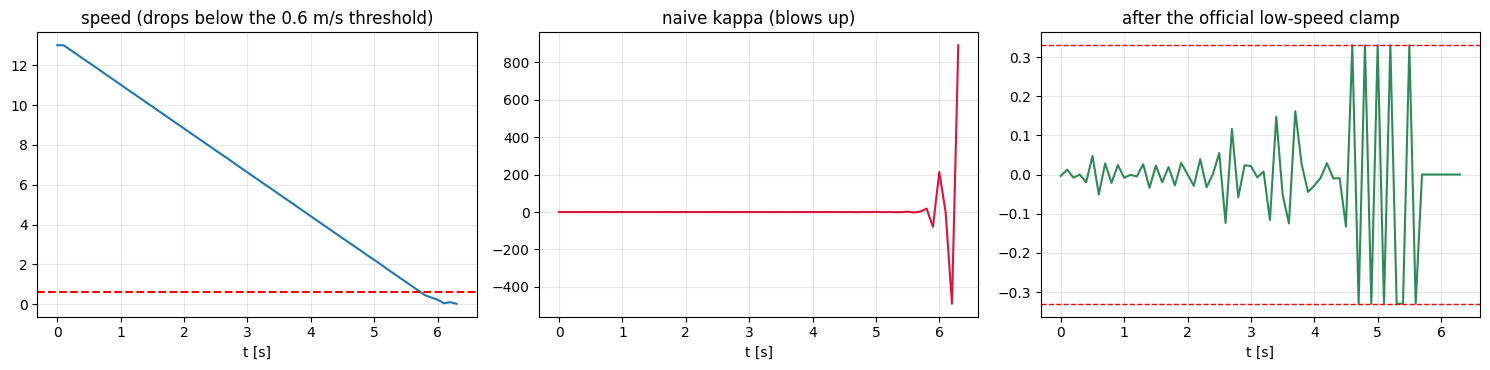

naive kappa の最大絶対値    :       890.81 1/m
クランプ後の最大絶対値      :       0.3300 1/m  (bounds=(-0.33, 0.33))
物理的にありえない倍率      : 2699.4 倍の逸脱

=> 低速クランプなしで学習すると、停車シーンの GT ラベルが巨大な曲率になり学習が壊れる。


In [5]:
def traj_to_action_naive(xy, v0, dt=DT):
    """正則化なしの素朴な逆変換。低速時の破綻を見るための比較用."""
    d = xy[..., 1:, :] - xy[..., :-1, :]
    d = torch.cat([xy[..., :1, :], d], dim=-2)          # (..., N, 2)
    v = torch.linalg.norm(d, dim=-1) / dt               # (..., N)
    theta = torch.atan2(d[..., 1], d[..., 0])           # (..., N)
    v_full = torch.cat([v0.unsqueeze(-1), v], dim=-1)   # (..., N+1)
    accel = (v_full[..., 1:] - v_full[..., :-1]) / dt   # (..., N)
    dtheta = torch.cat([theta[..., :1], theta[..., 1:] - theta[..., :-1]], dim=-1)
    s = dt * v_full[..., :-1] + (dt ** 2) / 2.0 * accel
    kappa = dtheta / s                                   # <-- s -> 0 で発散
    return accel, kappa, v_full


def apply_official_guards(kappa, v_full):
    """公式実装の低速クランプ + bounds クランプ."""
    low_speed = ((v_full[..., :-1].abs() < LOW_SPEED_CURVATURE_THRESHOLD_MPS)
                 | (v_full[..., 1:].abs() < LOW_SPEED_CURVATURE_THRESHOLD_MPS))
    kappa = kappa.clamp(min=CURVATURE_BOUNDS[0], max=CURVATURE_BOUNDS[1])
    return torch.where(low_speed, torch.zeros_like(kappa), kappa)


# 停止シナリオ: 途中で v が 0 に張り付く軌道を作って逆変換をかける
stop_act, stop_v0 = scenarios["Stop for static constraints"]
stop_act = stop_act.clone()
# 停止後も微小なヨー揺れがある現実的な状況を模擬（センサノイズ相当）
stop_act[..., 1] += torch.randn(1, N_WAYPOINTS) * 0.02
xy_stop, vel_stop, _ = action_space.action_to_traj(stop_act, torch.tensor([stop_v0]))
# 速度が負に行かないようにクリップした「実測風」軌道を作る
v_clipped = vel_stop.clamp(min=0.0)
xy_meas = torch.cumsum(v_clipped[..., :-1] * DT, dim=-1).unsqueeze(-1)
xy_meas = torch.cat([xy_meas, torch.randn(1, N_WAYPOINTS, 1) * 0.01], dim=-1)

accel_n, kappa_n, v_full = traj_to_action_naive(xy_meas, torch.tensor([stop_v0]))
kappa_guarded = apply_official_guards(kappa_n, v_full)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
axes[0].plot(t_grid, v_full[0, :-1]); axes[0].axhline(LOW_SPEED_CURVATURE_THRESHOLD_MPS, color="r", ls="--")
axes[0].set_title("speed (drops below the 0.6 m/s threshold)"); axes[0].set_xlabel("t [s]"); axes[0].grid(alpha=.3)
axes[1].plot(t_grid, kappa_n[0], color="crimson")
axes[1].set_title("naive kappa (blows up)"); axes[1].set_xlabel("t [s]"); axes[1].grid(alpha=.3)
axes[2].plot(t_grid, kappa_guarded[0], color="seagreen")
axes[2].axhline(CURVATURE_BOUNDS[1], color="r", ls="--", lw=1)
axes[2].axhline(CURVATURE_BOUNDS[0], color="r", ls="--", lw=1)
axes[2].set_title("after the official low-speed clamp"); axes[2].set_xlabel("t [s]"); axes[2].grid(alpha=.3)
plt.tight_layout()
plt.show()

naive_max = kappa_n.abs().max().item()
guard_max = kappa_guarded.abs().max().item()
print(f"naive kappa の最大絶対値    : {naive_max:12.2f} 1/m")
print(f"クランプ後の最大絶対値      : {guard_max:12.4f} 1/m  (bounds={CURVATURE_BOUNDS})")
print(f"物理的にありえない倍率      : {naive_max / CURVATURE_BOUNDS[1]:.1f} 倍の逸脱")
assert naive_max > CURVATURE_BOUNDS[1] * 10, "低速での発散が再現できていない"
assert guard_max <= CURVATURE_BOUNDS[1] + 1e-6, "クランプが効いていない"
print("\n=> 低速クランプなしで学習すると、停車シーンの GT ラベルが巨大な曲率になり学習が壊れる。")


## 4. Flow Matching — 公式実装の移植

学習データの構成と損失は非常に単純である。Gaussian 条件付き最適輸送パスなので

$$\boldsymbol{a}_t = t\,\boldsymbol{a} + (1-t)\,\boldsymbol{\epsilon},\qquad \mathbf{u}(\boldsymbol{a}_t\mid\boldsymbol{a})=\boldsymbol{a}-\boldsymbol{\epsilon}$$

となり、**回帰ターゲットが定数ベクトル $\boldsymbol{a}-\boldsymbol{\epsilon}$** になる。
ノイズスケジュールの設計が不要なのが diffusion に対する実装上の利点である。
推論は $\boldsymbol{a}_{t+\delta_t}=\boldsymbol{a}_t+\delta_t\,\mathbf{v}_\Theta$ の Euler 積分。


x_dims: (64, 2)


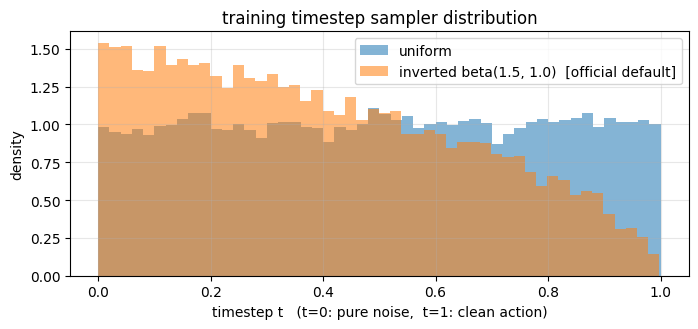

uniform: mean=0.5034   t<0.3 の割合=0.295
beta   : mean=0.3960   t<0.3 の割合=0.419

=> 公式デフォルトはノイズが多い領域 (t が小さい側) を重点的に学習させている。


In [6]:
class FlowMatching:
    """NVlabs/alpamayo2 の FlowMatching の移植."""

    def __init__(self, x_dims, num_inference_steps=NUM_INFERENCE_STEPS,
                 train_timestep_sampler="beta"):
        self.x_dims = x_dims
        self.num_inference_steps = num_inference_steps
        self.train_timestep_sampler = train_timestep_sampler
        if train_timestep_sampler == "beta":
            self.beta_dist = torch.distributions.beta.Beta(
                torch.tensor(1.5, dtype=torch.float32),
                torch.tensor(1.0, dtype=torch.float32),
            )
            self.beta_scale_constant = 0.999

    def sample_timesteps(self, batch_size, device="cpu"):
        if self.train_timestep_sampler == "uniform":
            return torch.rand((batch_size,), device=device)
        t = self.beta_dist.sample((batch_size,)).to(device)
        return self.beta_scale_constant - t * self.beta_scale_constant

    def construct_training_data(self, x):
        t = self.sample_timesteps(x.shape[0], x.device)
        while len(t.shape) < len(x.shape):
            t = t.unsqueeze(-1)
        noise = torch.randn_like(x)
        return {"x": x, "noisy_x": t * x + (1 - t) * noise, "timesteps": t, "noise": noise}

    @staticmethod
    def compute_loss_from_pred(training_data, pred):
        target = (training_data["x"] - training_data["noise"]).to(dtype=pred.dtype)
        return F.mse_loss(target, pred)

    @torch.no_grad()
    def sample(self, batch_size, step_fn, device="cpu", inference_step=None,
               return_all_steps=False, temperature=1.0):
        inference_step = inference_step or self.num_inference_steps
        x = torch.randn(batch_size, *self.x_dims, device=device) * temperature
        time_steps = torch.linspace(0.0, 1.0, inference_step + 1, device=device)
        n_dim = len(self.x_dims)
        all_steps = [x] if return_all_steps else None
        for i in range(inference_step):
            dt = (time_steps[i + 1] - time_steps[i]).view(1, *[1] * n_dim).expand(batch_size, *[1] * n_dim)
            t_start = time_steps[i].view(1, *[1] * n_dim).expand(batch_size, *[1] * n_dim)
            v = step_fn(x=x, t=t_start)
            x = x + dt * v
            if return_all_steps:
                all_steps.append(x)
        if return_all_steps:
            return torch.stack(all_steps, dim=1), time_steps
        return x


diffusion = FlowMatching(x_dims=action_space.get_action_space_dims())
print("x_dims:", diffusion.x_dims)

# beta サンプラ vs uniform サンプラの分布比較
t_beta = FlowMatching(x_dims=(1,), train_timestep_sampler="beta").sample_timesteps(20000)
t_unif = FlowMatching(x_dims=(1,), train_timestep_sampler="uniform").sample_timesteps(20000)

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(t_unif.numpy(), bins=50, alpha=.55, density=True, label="uniform")
ax.hist(t_beta.numpy(), bins=50, alpha=.55, density=True, label="inverted beta(1.5, 1.0)  [official default]")
ax.set_xlabel("timestep t   (t=0: pure noise,  t=1: clean action)")
ax.set_ylabel("density"); ax.legend(); ax.grid(alpha=.3)
ax.set_title("training timestep sampler distribution")
plt.tight_layout()
plt.show()

print(f"uniform: mean={t_unif.mean():.4f}   t<0.3 の割合={float((t_unif < 0.3).float().mean()):.3f}")
print(f"beta   : mean={t_beta.mean():.4f}   t<0.3 の割合={float((t_beta < 0.3).float().mean()):.3f}")
assert t_beta.mean() < t_unif.mean(), "beta サンプラはノイズ側 (t 小) に偏るはず"
print("\n=> 公式デフォルトはノイズが多い領域 (t が小さい側) を重点的に学習させている。")


## 5. Action expert の入力射影 — Fourier 特徴

action（加速度・曲率という 2 個のスカラー）と diffusion timestep を、そのまま Linear に通すのではなく
**対数間隔の周波数を持つ Fourier 特徴**に展開してから MLP に入れる。NeRF 由来の定石で、
低次元スカラーの細かい違いをネットワークが表現できるようにする。


Fourier 周波数 (logspace 0 -> log10(100), 10 本):
   [  1.      1.668   2.783   4.642   7.743  12.915  21.544  35.938  59.948
 100.   ]
入力 1 スカラー -> 20 次元


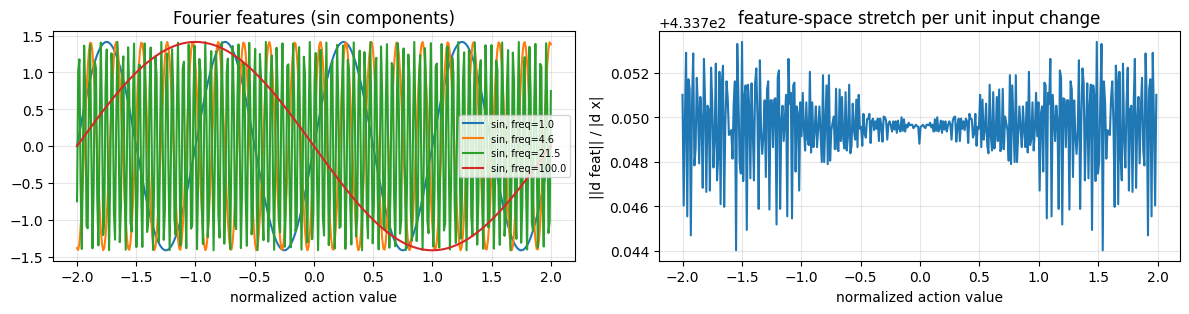


生スカラーなら伸びは常に 1.0 だが、Fourier 特徴では平均 433.7 倍に拡大される。
=> 微小な加速度差をネットワークが区別できるようになる。


In [7]:
class FourierEncoderV2(nn.Module):
    """NVlabs/alpamayo2 : models/action_in_proj.py の移植."""

    def __init__(self, dim, max_freq=100.0):
        super().__init__()
        assert dim % 2 == 0, "dim must be even"
        half = dim // 2
        freqs = torch.logspace(0, math.log10(max_freq), steps=half)
        self.out_dim = dim
        self.register_buffer("freqs", freqs[None, :])

    def forward(self, x):
        arg = x[..., None] * self.freqs * 2 * torch.pi
        return torch.cat([torch.sin(arg), torch.cos(arg)], -1) * math.sqrt(2)


class RMSNorm(nn.Module):
    def __init__(self, dim, eps):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        out = x.float() * torch.rsqrt(x.float().pow(2).mean(-1, keepdim=True) + self.eps)
        return out.type_as(x) * self.weight


class MLPEncoder(nn.Module):
    def __init__(self, num_input_feats, num_enc_layers, hidden_size, outdim):
        super().__init__()
        layers = [nn.Linear(num_input_feats, hidden_size), nn.SiLU()]
        for i in range(num_enc_layers):
            if i < num_enc_layers - 1:
                layers += [RMSNorm(hidden_size, eps=1e-5), nn.Linear(hidden_size, hidden_size), nn.SiLU()]
            else:
                layers += [RMSNorm(hidden_size, eps=1e-5), nn.Linear(hidden_size, outdim)]
        self.trunk = nn.Sequential(*layers)

    def forward(self, x):
        return self.trunk(x)


class PerWaypointActionInProjV2(nn.Module):
    """action (B, T, 2) + timestep -> expert token embeddings (B, T, out_dim)."""

    def __init__(self, in_dims, out_dim, num_enc_layers=4, hidden_size=256,
                 max_freq=100.0, num_fourier_feats=20):
        super().__init__()
        self.sinus = nn.ModuleList(
            FourierEncoderV2(dim=num_fourier_feats, max_freq=max_freq) for _ in range(in_dims[-1]))
        self.timestep_fourier_encoder = FourierEncoderV2(dim=num_fourier_feats, max_freq=max_freq)
        num_input_feats = sum(e.out_dim for e in self.sinus) + self.timestep_fourier_encoder.out_dim
        self.encoder = MLPEncoder(num_input_feats, num_enc_layers, hidden_size, out_dim)
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, x, timesteps):
        b, n, _ = x.shape
        x = x.float()
        timesteps = timesteps.float()
        action_feats = torch.cat([enc(x[:, :, i]) for i, enc in enumerate(self.sinus)], dim=-1)
        ts_feats = self.timestep_fourier_encoder(timesteps[..., -1])
        ts_feats = ts_feats.repeat(1, n, 1)
        feats = torch.cat((action_feats, ts_feats), dim=-1)
        encoded = self.encoder(feats.flatten(0, 1)).reshape(b, n, -1)
        return self.norm(encoded)


fe = FourierEncoderV2(dim=20, max_freq=100.0)
xs = torch.linspace(-2, 2, 400)
feat = fe(xs)
print("Fourier 周波数 (logspace 0 -> log10(100), 10 本):")
print("  ", np.round(fe.freqs[0].numpy(), 3))
print(f"入力 1 スカラー -> {feat.shape[-1]} 次元")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
for i in [0, 3, 6, 9]:
    axes[0].plot(xs, feat[:, i], label=f"sin, freq={fe.freqs[0, i]:.1f}")
axes[0].set_title("Fourier features (sin components)"); axes[0].set_xlabel("normalized action value")
axes[0].legend(fontsize=7); axes[0].grid(alpha=.3)

# 近接する 2 つの入力値が特徴空間でどれだけ離れるか
d_raw = (xs[1:] - xs[:-1]).abs()
d_feat = (feat[1:] - feat[:-1]).norm(dim=-1)
axes[1].plot(xs[:-1], d_feat / d_raw)
axes[1].set_title("feature-space stretch per unit input change"); axes[1].set_xlabel("normalized action value")
axes[1].set_ylabel("||d feat|| / |d x|"); axes[1].grid(alpha=.3)
plt.tight_layout()
plt.show()

print(f"\n生スカラーなら伸びは常に 1.0 だが、Fourier 特徴では平均 {float((d_feat/d_raw).mean()):.1f} 倍に拡大される。")
print("=> 微小な加速度差をネットワークが区別できるようになる。")


## 6. 合成マルチカメラ運転シーンと Chain-of-Causation ラベル

ここから mini-Alpamayo を組み立てる。まず入力データを作る。

- **3 カメラ × 4 フレーム**（実物は 6 カメラ × 4 フレーム）の 24×24 グレースケール
- `front_wide` には先行車（距離に応じて大きさが変わる箱）と信号（上部の輝点）
- `cross_left` / `cross_right` には車線境界が横オフセットに応じて動く
- ego 履歴として初速 $v_0$

CoC の driving decision は公式の閉集合語彙のサブセットを使い、
**シーンから決定的にラベルが決まる**ルールベースの「熟練ドライバ」で GT を作る。


train: images (1536, 3, 4, 24, 24)  action (1536, 64, 2)
test : images (384, 3, 4, 24, 24)  action (384, 64, 2)

longitudinal decision の分布: {'Set speed tracking': 868, 'Lead obstacle following': 346, 'Stop for static constraints': 322}
lateral decision の分布     : {'Lane keeping & centering': 538, 'Lane change (lateral push)': 368, 'Turn (intersection)': 630}


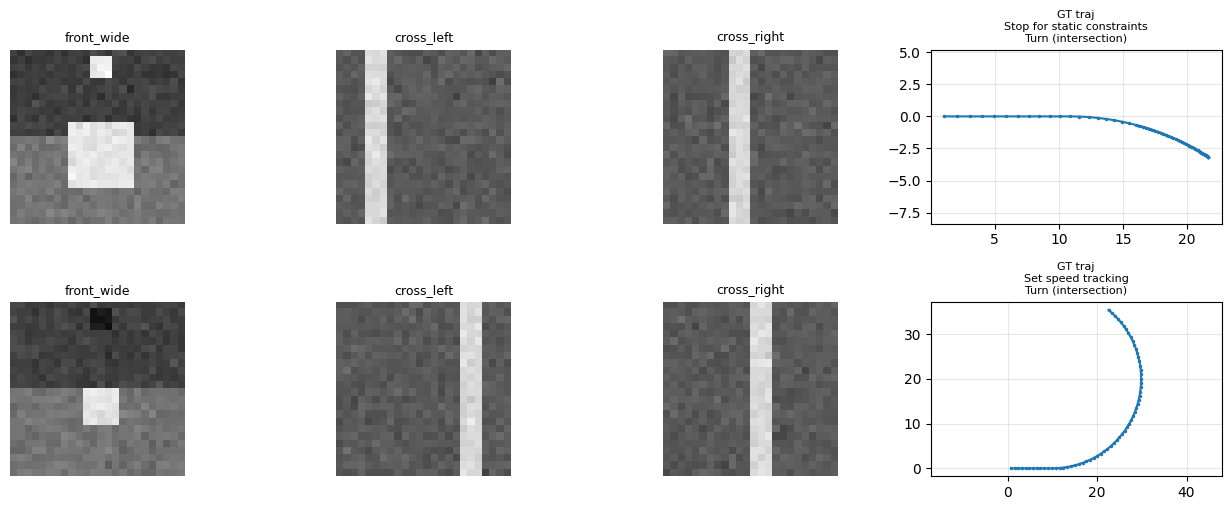

In [8]:
# Chain-of-Causation : driving decision の閉集合 (公式 Table 1 のサブセット)
LON_DECISIONS = ["Set speed tracking", "Lead obstacle following", "Stop for static constraints"]
LAT_DECISIONS = ["Lane keeping & centering", "Lane change (lateral push)", "Turn (intersection)"]

CAM_NAMES = ["front_wide", "cross_left", "cross_right"]
N_CAM, N_FRAME, IMG = 3, 4, 24


def render_scene(lead_dist, light_red, lane_offset, turn_cmd, lane_change_cmd, rng):
    """(N_CAM, N_FRAME, IMG, IMG) のシーンを描く. 値域 [0, 1]."""
    imgs = np.zeros((N_CAM, N_FRAME, IMG, IMG), dtype=np.float32)
    for f in range(N_FRAME):
        # --- front_wide: 路面 + 先行車 + 信号
        fw = np.full((IMG, IMG), 0.25, dtype=np.float32)
        fw[IMG // 2:, :] = 0.45                                  # 路面
        if lead_dist < 60:
            # 先行車: 近いほど大きく、フレームが進むほど僅かに接近
            sz = int(np.clip(14 - lead_dist / 5.0 + f * 0.3, 2, 12))
            cy, cx = IMG // 2 + 2, IMG // 2
            fw[cy - sz // 2:cy + sz // 2 + 1, cx - sz // 2:cx + sz // 2 + 1] = 0.9
        fw[1:4, IMG // 2 - 1:IMG // 2 + 2] = 0.95 if light_red else 0.10   # 信号
        imgs[0, f] = fw

        # --- cross_left / cross_right: 車線境界の横位置
        for ci, sign in [(1, -1.0), (2, +1.0)]:
            side = np.full((IMG, IMG), 0.35, dtype=np.float32)
            col = int(np.clip(IMG / 2 + sign * lane_offset * 2.5 + turn_cmd * 4.0
                              + lane_change_cmd * 3.0, 1, IMG - 2))
            side[:, col - 1:col + 2] = 0.85
            imgs[ci, f] = side
    imgs += rng.normal(0, 0.03, imgs.shape).astype(np.float32)
    return np.clip(imgs, 0.0, 1.0)


def expert_driver(lead_dist, light_red, lane_offset, turn_cmd, lane_change_cmd, v0):
    """ルールベースの熟練ドライバ。CoC decision と action プロファイルを返す."""
    t = np.arange(N_WAYPOINTS) * DT

    if light_red and lead_dist > 15:
        # 完全停止する
        lon = "Stop for static constraints"
        accel = np.full(N_WAYPOINTS, -min(2.5, v0 / 3.0))
    elif lead_dist < 25:
        # 先行車に追従して減速するが、停止はしない (Stop と区別できるようにする)
        lon = "Lead obstacle following"
        accel = -1.6 * np.exp(-t / 3.0) * (25 - lead_dist) / 25 * 2.0
        v_prof = v0 + np.cumsum(accel * DT)
        if v_prof.min() < 1.5:                      # 停止してしまう場合は減速を弱める
            accel *= (v0 - 1.5) / max(v0 - v_prof.min(), 1e-6)
    else:
        lon = "Set speed tracking"
        accel = 0.9 * np.exp(-t / 2.5)

    if turn_cmd != 0:
        # 交差点旋回: 一定曲率で大きくヨーが変わる
        lat = "Turn (intersection)"
        kappa = np.where(t > 1.2, 0.05 * np.sign(turn_cmd), 0.0)
    elif lane_change_cmd != 0:
        # レーンチェンジ: S 字なので最終ヨーは 0 に戻るが横に大きくずれる
        lat = "Lane change (lateral push)"
        kappa = 0.010 * np.sign(lane_change_cmd) * np.sin(2 * np.pi * t / 5.0) * (t < 5.0)
    else:
        # 車線維持: 中央へ戻る小さな S 字。最終ヨー 0、横ずれも小さい
        lat = "Lane keeping & centering"
        kappa = -0.002 * lane_offset * np.sin(2 * np.pi * t / 3.0) * (t < 3.0)

    return lon, lat, accel.astype(np.float32), kappa.astype(np.float32)


def make_dataset(n, seed):
    rng = np.random.default_rng(seed)
    X = np.zeros((n, N_CAM, N_FRAME, IMG, IMG), dtype=np.float32)
    V0 = np.zeros(n, dtype=np.float32)
    A = np.zeros((n, N_WAYPOINTS, 2), dtype=np.float32)
    LON = np.zeros(n, dtype=np.int64)
    LAT = np.zeros(n, dtype=np.int64)
    for i in range(n):
        lead_dist = rng.uniform(8, 80)
        light_red = bool(rng.random() < 0.25)
        lane_offset = rng.uniform(-1.2, 1.2)
        turn_cmd = int(rng.choice([0, 0, 0, -1, 1]))
        lane_change_cmd = 0 if turn_cmd != 0 else int(rng.choice([0, 0, 0, -1, 1]))
        v0 = rng.uniform(4.0, 16.0)

        X[i] = render_scene(lead_dist, light_red, lane_offset, turn_cmd, lane_change_cmd, rng)
        V0[i] = v0
        lon, lat, accel, kappa = expert_driver(lead_dist, light_red, lane_offset,
                                               turn_cmd, lane_change_cmd, v0)
        A[i, :, 0] = (accel - ACCEL_MEAN) / ACCEL_STD
        A[i, :, 1] = (kappa - CURVATURE_MEAN) / CURVATURE_STD
        LON[i] = LON_DECISIONS.index(lon)
        LAT[i] = LAT_DECISIONS.index(lat)
    return (torch.from_numpy(X), torch.from_numpy(V0), torch.from_numpy(A),
            torch.from_numpy(LON), torch.from_numpy(LAT))


Xtr, Vtr, Atr, LONtr, LATtr = make_dataset(1536, seed=1)
Xte, Vte, Ate, LONte, LATte = make_dataset(384, seed=2)
print(f"train: images {tuple(Xtr.shape)}  action {tuple(Atr.shape)}")
print(f"test : images {tuple(Xte.shape)}  action {tuple(Ate.shape)}")
print(f"\nlongitudinal decision の分布: "
      f"{ {LON_DECISIONS[i]: int((LONtr == i).sum()) for i in range(len(LON_DECISIONS))} }")
print(f"lateral decision の分布     : "
      f"{ {LAT_DECISIONS[i]: int((LATtr == i).sum()) for i in range(len(LAT_DECISIONS))} }")

# 入力シーンの可視化
fig, axes = plt.subplots(2, N_CAM + 1, figsize=(13, 5.2))
for row, idx in enumerate([int((LONtr == 2).nonzero()[0]), int((LATtr == 2).nonzero()[0])]):
    for c in range(N_CAM):
        axes[row, c].imshow(Xtr[idx, c, -1], cmap="gray", vmin=0, vmax=1)
        axes[row, c].set_title(f"{CAM_NAMES[c]}", fontsize=9)
        axes[row, c].axis("off")
    xy, _, _ = action_space.action_to_traj(Atr[idx:idx + 1], Vtr[idx:idx + 1])
    axes[row, -1].plot(xy[0, :, 0], xy[0, :, 1], marker=".", ms=3)
    axes[row, -1].set_title(f"GT traj\n{LON_DECISIONS[LONtr[idx]]}\n{LAT_DECISIONS[LATtr[idx]]}", fontsize=8)
    axes[row, -1].axis("equal"); axes[row, -1].grid(alpha=.3)
plt.tight_layout()
plt.show()


## 7. mini-Alpamayo — VLM バックボーン + action expert

実物の forward パスは以下だった。

```
カメラ -> トークン化 -> VLM prefill (past_key_values) -> CoC 生成
                                    |
                                    +-> action expert が同じ KV に attend -> flow matching -> trajectory
```

ここでは「VLM prefill の hidden states を expert が使い回す」という**構造だけ**を保存する。
expert は `expert_non_causal_attention=True` に相当する双方向 self-attention を waypoint 間に持ち、
バックボーンのトークンには cross-attention で接続する。


In [9]:
D_MODEL = 128


class TinyVLMBackbone(nn.Module):
    """実物の 32B Cosmos 3 Super Reasoner の代用。構造 (画像->トークン->Transformer) だけ保つ."""

    def __init__(self, d_model=D_MODEL, n_layers=3, n_heads=4):
        super().__init__()
        self.patch = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), nn.SiLU(),   # 24 -> 12
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.SiLU(),  # 12 -> 6
            nn.Conv2d(32, d_model, 3, stride=2, padding=1),        # 6 -> 3
        )
        n_tok = N_CAM * N_FRAME * 9   # 3x3 patch/画像
        # (1, N_CAM, 1, 1, D) と (1, 1, N_FRAME, 1, D) で (B, C, F, 9, D) にブロードキャストする
        self.cam_embed = nn.Parameter(torch.randn(1, N_CAM, 1, 1, d_model) * 0.02)
        self.time_embed = nn.Parameter(torch.randn(1, 1, N_FRAME, 1, d_model) * 0.02)
        self.pos = nn.Parameter(torch.randn(1, n_tok + 1, d_model) * 0.02)
        self.ego_proj = nn.Linear(1, d_model)   # ego 履歴 (初速) のトークン
        enc = nn.TransformerEncoderLayer(d_model, n_heads, d_model * 4, batch_first=True,
                                         norm_first=True, dropout=0.0, activation="gelu")
        # norm_first=True のときは最終 LayerNorm が必須 (無いと残差の分散が発散する)
        self.encoder = nn.TransformerEncoder(enc, n_layers, norm=nn.LayerNorm(d_model))
        # CoC の閉集合 decision ヘッド (実物では自己回帰テキスト生成に相当)
        self.lon_head = nn.Linear(d_model, len(LON_DECISIONS))
        self.lat_head = nn.Linear(d_model, len(LAT_DECISIONS))

    def forward(self, imgs, v0):
        b = imgs.shape[0]
        x = imgs.reshape(b * N_CAM * N_FRAME, 1, IMG, IMG)
        x = self.patch(x)                                   # (B*C*F, D, 3, 3)
        x = x.flatten(2).transpose(1, 2)                    # (B*C*F, 9, D)
        x = x.reshape(b, N_CAM, N_FRAME, 9, D_MODEL)
        x = x + self.cam_embed + self.time_embed
        x = x.reshape(b, N_CAM * N_FRAME * 9, D_MODEL)
        ego_tok = self.ego_proj((v0 / 10.0).unsqueeze(-1)).unsqueeze(1)   # (B, 1, D)
        x = torch.cat([ego_tok, x], dim=1) + self.pos
        h = self.encoder(x)                                 # 実物の past_key_values に相当
        pooled = h[:, 0]
        return h, self.lon_head(pooled), self.lat_head(pooled)


class ActionExpert(nn.Module):
    """VLM の hidden states を条件に flow matching のベクトル場を予測する."""

    def __init__(self, d_model=D_MODEL, n_layers=3, n_heads=4):
        super().__init__()
        self.action_in_proj = PerWaypointActionInProjV2(
            in_dims=list(action_space.get_action_space_dims()), out_dim=d_model, hidden_size=256)
        layer = nn.TransformerDecoderLayer(d_model, n_heads, d_model * 4, batch_first=True,
                                           norm_first=True, dropout=0.0, activation="gelu")
        # self-attn は非因果 (全 waypoint が相互に見える) = expert_non_causal_attention=True 相当
        self.expert = nn.TransformerDecoder(layer, n_layers, norm=nn.LayerNorm(d_model))
        self.wp_pos = nn.Parameter(torch.randn(1, N_WAYPOINTS, d_model) * 0.02)
        self.action_out_proj = nn.Linear(d_model, action_space.get_action_space_dims()[-1])

    def forward(self, noisy_action, timesteps, vlm_hidden):
        emb = self.action_in_proj(noisy_action, timesteps) + self.wp_pos
        out = self.expert(tgt=emb, memory=vlm_hidden)   # memory = VLM の KV キャッシュ相当
        return self.action_out_proj(out)


class MiniAlpamayo(nn.Module):
    def __init__(self):
        super().__init__()
        self.vlm = TinyVLMBackbone()
        self.action_expert = ActionExpert()

    def forward(self, imgs, v0):
        return self.vlm(imgs, v0)


model = MiniAlpamayo()
n_vlm = sum(p.numel() for p in model.vlm.parameters())
n_exp = sum(p.numel() for p in model.action_expert.parameters())
print(f"VLM backbone : {n_vlm:,} params  (実物: 32,000,000,000)")
print(f"action expert: {n_exp:,} params  (実物:  2,300,000,000)")
print(f"expert 比率  : {n_exp / (n_vlm + n_exp):.1%}   (実物: {2.3 / 34.0:.1%})")


VLM backbone : 652,742 params  (実物: 32,000,000,000)
action expert: 1,049,602 params  (実物:  2,300,000,000)
expert 比率  : 61.7%   (実物: 6.8%)


/tmp/ipykernel_1042735/2428629282.py:23: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc, n_layers, norm=nn.LayerNorm(d_model))


### 7.1 学習

損失は 2 本である。

- CoC decision の cross-entropy（実物では reasoning テキストの next-token prediction）
- action expert の flow matching 損失 $\|\mathbf{v}_\Theta - (\boldsymbol{a}-\boldsymbol{\epsilon})\|^2$

実物の Stage 1 では expert の勾配が VLM に流れないよう KV キャッシュに stop-gradient をかけるが、
ここでは 1 段で同時に学習する（データが小さく、両者を同時に学ばせた方が収束が速いため）。


In [10]:
import time

opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
EPOCHS, BATCH = 45, 64
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

history = {"flow": [], "coc": [], "test_flow": []}
t_start = time.time()

for ep in range(EPOCHS):
    model.train()
    perm = torch.randperm(len(Xtr))
    ep_flow, ep_coc, nb = 0.0, 0.0, 0
    for i in range(0, len(Xtr), BATCH):
        idx = perm[i:i + BATCH]
        imgs, v0, act = Xtr[idx], Vtr[idx], Atr[idx]
        lon_gt, lat_gt = LONtr[idx], LATtr[idx]

        hidden, lon_logits, lat_logits = model(imgs, v0)

        # --- Chain-of-Causation の decision 損失
        loss_coc = F.cross_entropy(lon_logits, lon_gt) + F.cross_entropy(lat_logits, lat_gt)

        # --- flow matching 損失 (公式実装と同じ構成)
        td = diffusion.construct_training_data(act)
        pred_v = model.action_expert(td["noisy_x"], td["timesteps"], hidden)
        loss_flow = FlowMatching.compute_loss_from_pred(td, pred_v)

        loss = loss_flow + 0.5 * loss_coc
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        ep_flow += loss_flow.item(); ep_coc += loss_coc.item(); nb += 1
    sched.step()

    model.eval()
    with torch.no_grad():
        h_te, _, _ = model(Xte, Vte)
        td_te = diffusion.construct_training_data(Ate)
        pv_te = model.action_expert(td_te["noisy_x"], td_te["timesteps"], h_te)
        test_flow = FlowMatching.compute_loss_from_pred(td_te, pv_te).item()

    history["flow"].append(ep_flow / nb)
    history["coc"].append(ep_coc / nb)
    history["test_flow"].append(test_flow)
    if ep % 4 == 0 or ep == EPOCHS - 1:
        print(f"epoch {ep:2d}  flow={ep_flow/nb:.4f}  coc={ep_coc/nb:.4f}  test_flow={test_flow:.4f}")

print(f"\n学習時間: {time.time() - t_start:.1f} s (CPU)")
print(f"flow matching 損失: {history['flow'][0]:.4f} -> {history['flow'][-1]:.4f} "
      f"({(1 - history['flow'][-1]/history['flow'][0])*100:.1f}% 減少)")
assert history["flow"][-1] < history["flow"][0] * 0.5, "flow matching 損失が十分に下がっていない"


epoch  0  flow=3.3665  coc=2.1264  test_flow=2.8357


epoch  4  flow=2.8691  coc=1.8239  test_flow=2.9237


epoch  8  flow=2.8688  coc=1.6160  test_flow=2.8078


epoch 12  flow=2.7045  coc=1.6124  test_flow=2.5873


epoch 16  flow=1.7599  coc=1.1513  test_flow=1.5976


...

epoch 28  flow=1.2839  coc=0.4705  test_flow=1.2816


epoch 32  flow=1.1728  coc=0.3053  test_flow=1.1244


epoch 36  flow=1.0218  coc=0.1975  test_flow=0.9988


epoch 40  flow=0.9307  coc=0.1376  test_flow=0.9242


epoch 44  flow=0.8970  coc=0.1185  test_flow=0.9056

学習時間: 572.8 s (CPU)
flow matching 損失: 3.3665 -> 0.8970 (73.4% 減少)


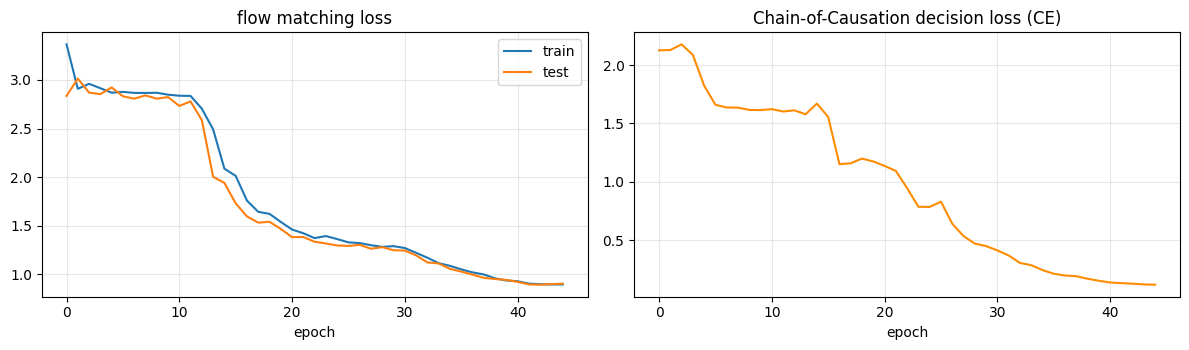

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].plot(history["flow"], label="train"); axes[0].plot(history["test_flow"], label="test")
axes[0].set_title("flow matching loss"); axes[0].set_xlabel("epoch"); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(history["coc"], color="darkorange")
axes[1].set_title("Chain-of-Causation decision loss (CE)"); axes[1].set_xlabel("epoch"); axes[1].grid(alpha=.3)
plt.tight_layout()
plt.show()


## 8. 推論 — 10 ステップの Euler 積分で trajectory を生成する

公式のデフォルトと同じ `inference_step=10` でサンプリングし、minADE で評価する。
実物と同様、**expert は VLM を再実行せず prefill 済みの hidden states だけを条件にする**。


In [12]:
@torch.no_grad()
def predict(imgs, v0, num_samples=1, inference_step=NUM_INFERENCE_STEPS, return_all_steps=False):
    model.eval()
    hidden, lon_logits, lat_logits = model(imgs, v0)          # <- VLM prefill は 1 回だけ
    b = imgs.shape[0]
    hidden_rep = hidden.repeat_interleave(num_samples, dim=0)

    def step_fn(x, t):
        # t は FlowMatching._euler が (B, 1, 1) で渡してくる。
        # PerWaypointActionInProjV2 は timesteps[..., -1] -> (B, 1) を期待するのでそのまま渡す。
        return model.action_expert(x, t, hidden_rep)

    out = diffusion.sample(b * num_samples, step_fn, inference_step=inference_step,
                           return_all_steps=return_all_steps)
    if return_all_steps:
        traj_steps, tgrid = out
        return traj_steps, tgrid, lon_logits, lat_logits
    act = out.view(b, num_samples, N_WAYPOINTS, 2)
    return act, lon_logits, lat_logits


def min_ade(pred_act, gt_act, v0, k=6):
    """minADE_k: k サンプル中 GT に最も近いものの平均距離."""
    b, n = pred_act.shape[0], pred_act.shape[1]
    xy_pred, _, _ = action_space.action_to_traj(
        pred_act.reshape(b * n, N_WAYPOINTS, 2), v0.repeat_interleave(n))
    xy_pred = xy_pred.reshape(b, n, N_WAYPOINTS, 2)
    xy_gt, _, _ = action_space.action_to_traj(gt_act, v0)
    d = (xy_pred - xy_gt.unsqueeze(1)).norm(dim=-1).mean(-1)   # (B, n)
    return d.min(dim=1).values


pred_act, lon_logits, lat_logits = predict(Xte, Vte, num_samples=6)
ade6 = min_ade(pred_act, Ate, Vte)

lon_acc = (lon_logits.argmax(-1) == LONte).float().mean().item()
lat_acc = (lat_logits.argmax(-1) == LATte).float().mean().item()

print(f"minADE_6 @6.4s : {ade6.mean():.4f} m   (中央値 {ade6.median():.4f} m)")
print(f"CoC longitudinal decision accuracy : {lon_acc:.3f}")
print(f"CoC lateral      decision accuracy : {lat_acc:.3f}")
print(f"action が物理境界内の割合           : {action_space.is_within_bounds(pred_act.reshape(-1, N_WAYPOINTS, 2)).float().mean():.3f}")

assert ade6.mean() < 3.0, f"minADE_6 が大きすぎる: {ade6.mean():.3f}"
assert lon_acc > 0.75, f"longitudinal decision accuracy が低い: {lon_acc:.3f}"
assert lat_acc > 0.75, f"lateral decision accuracy が低い: {lat_acc:.3f}"
print("\nすべてのチェックを通過")


minADE_6 @6.4s : 1.8697 m   (中央値 1.3310 m)
CoC longitudinal decision accuracy : 0.990
CoC lateral      decision accuracy : 0.953
action が物理境界内の割合           : 1.000

すべてのチェックを通過


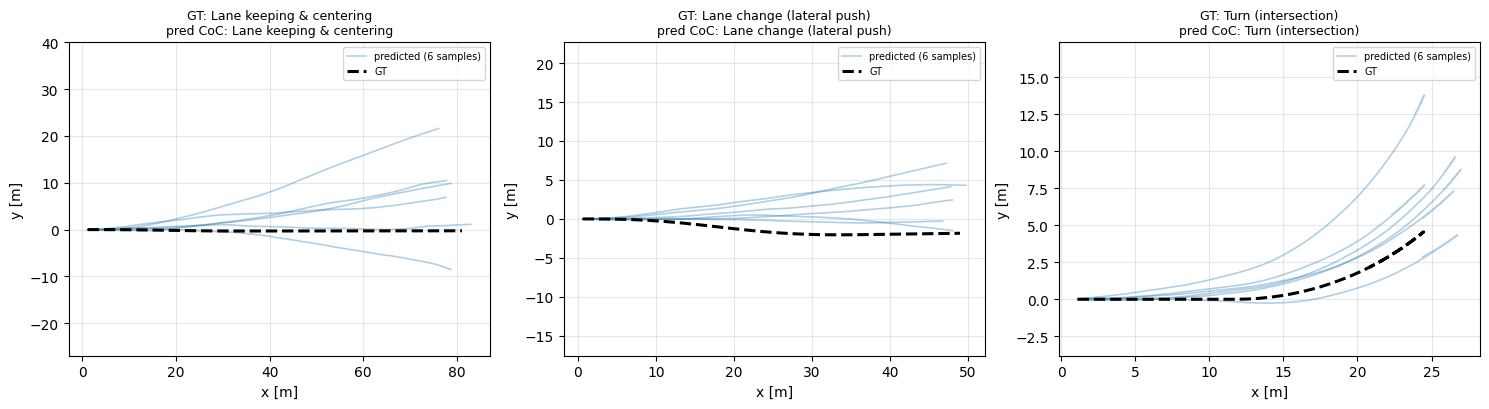

In [13]:
# 予測軌道の可視化 (各 lateral decision から 1 例ずつ)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, lat_id in zip(axes, range(len(LAT_DECISIONS))):
    idx = int((LATte == lat_id).nonzero()[0])
    xy_gt, _, _ = action_space.action_to_traj(Ate[idx:idx+1], Vte[idx:idx+1])
    xy_pr, _, _ = action_space.action_to_traj(pred_act[idx], Vte[idx:idx+1].repeat(6))
    for s in range(6):
        ax.plot(xy_pr[s, :, 0], xy_pr[s, :, 1], color="tab:blue", alpha=.35, lw=1.2,
                label="predicted (6 samples)" if s == 0 else None)
    ax.plot(xy_gt[0, :, 0], xy_gt[0, :, 1], color="k", lw=2.2, ls="--", label="GT")
    pred_lat = LAT_DECISIONS[lat_logits[idx].argmax().item()]
    ax.set_title(f"GT: {LAT_DECISIONS[lat_id]}\npred CoC: {pred_lat}", fontsize=9)
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.axis("equal"); ax.grid(alpha=.3); ax.legend(fontsize=7)
plt.tight_layout()
plt.show()


### 8.1 Euler 積分の途中経過を見る

$\boldsymbol{a}_0\sim\mathcal{N}(\mathbf{0},\mathbf{I})$ の純ノイズが 10 ステップで軌道になる過程を可視化する。
**64 waypoint が同時にデノイズされる**ため、系列全体の滑らかさが自然に保たれる点が
自己回帰デコードとの本質的な違いである。


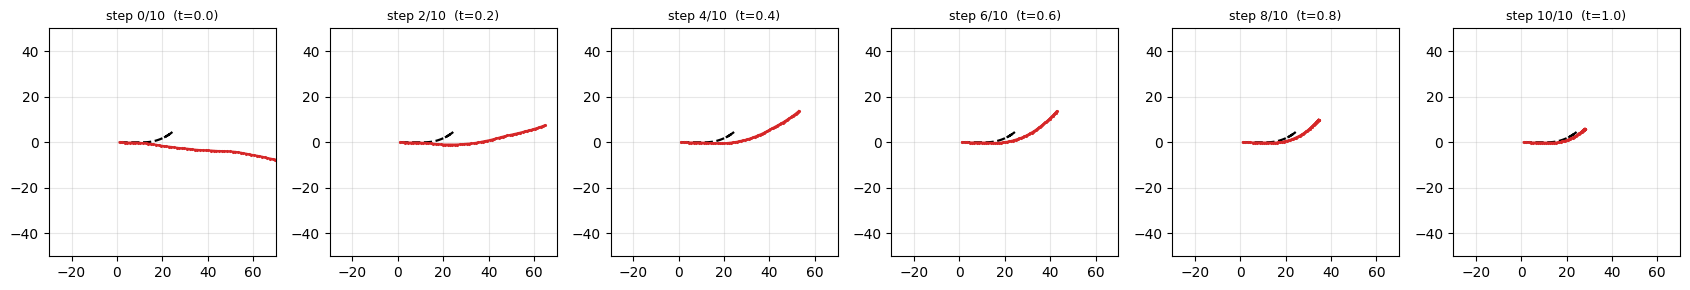

step  0/10 (t=0.0): 平均距離誤差 =   19.733 m
step  2/10 (t=0.2): 平均距離誤差 =   15.740 m
step  4/10 (t=0.4): 平均距離誤差 =   12.050 m
step  6/10 (t=0.6): 平均距離誤差 =    8.656 m
step  8/10 (t=0.8): 平均距離誤差 =    5.454 m
step 10/10 (t=1.0): 平均距離誤差 =    2.338 m


In [14]:
idx = int((LATte == 2).nonzero()[0])   # Turn のサンプル
steps, tgrid, _, _ = predict(Xte[idx:idx+1], Vte[idx:idx+1], num_samples=1, return_all_steps=True)

show = [0, 2, 4, 6, 8, 10]
fig, axes = plt.subplots(1, len(show), figsize=(17, 3.0))
xy_gt, _, _ = action_space.action_to_traj(Ate[idx:idx+1], Vte[idx:idx+1])
for ax, s in zip(axes, show):
    xy, _, _ = action_space.action_to_traj(steps[:, s], Vte[idx:idx+1])
    ax.plot(xy_gt[0, :, 0], xy_gt[0, :, 1], color="k", ls="--", lw=1.6)
    ax.plot(xy[0, :, 0], xy[0, :, 1], color="tab:red", marker=".", ms=2.5)
    ax.set_title(f"step {s}/10  (t={tgrid[s]:.1f})", fontsize=9)
    ax.grid(alpha=.3); ax.set_xlim(-30, 70); ax.set_ylim(-50, 50)
plt.tight_layout()
plt.show()

for s in show:
    xy, _, _ = action_space.action_to_traj(steps[:, s], Vte[idx:idx+1])
    err = (xy - xy_gt).norm(dim=-1).mean().item()
    print(f"step {s:2d}/10 (t={tgrid[s]:.1f}): 平均距離誤差 = {err:8.3f} m")


## 9. Flow matching vs 自己回帰デコード — comfort の差はどこから来るか

論文 Table 12 は、自己回帰デコードの Comfort (Accel) が 44.05%、flow matching が 97.38% だったと報告する。
原因は「自己回帰は 1 waypoint ずつ独立にサンプリングするため隣接点の滑らかさが保証されない」ことである。

この節では 3 つのことを順に行う。まず **本 notebook の toy expert が実際にどれくらい滑らかな出力を
出しているのかを測る**（結論を先に言うと、良くない）。次にその原因を切り分ける。
最後に、主張されているメカニズム自体を toy モデルの性能に依存しない形で確認する。

自分のモデルが再現できなかったことを隠して「論文の通りになりました」と書くのは、
このレポートの目的（実装レベルで理解する）に反する。


In [15]:
def comfort_metrics(act, v0):
    """jerk RMS と、加速度が快適域 (|a| < 2.0 m/s^2) に収まる割合."""
    accel = act[..., 0] * ACCEL_STD + ACCEL_MEAN
    jerk = (accel[..., 1:] - accel[..., :-1]) / DT
    jerk_rms = jerk.pow(2).mean(-1).sqrt()
    comfort = (accel.abs() < 2.0).float().mean(-1)
    return jerk_rms, comfort


K = 8
samples, _, _ = predict(Xte, Vte, num_samples=K)   # (B, K, N, 2) — joint サンプル
pred_fm = samples[:, 0]

# 疑似自己回帰: waypoint ごとに独立に別サンプルを選ぶ -> 周辺分布は同一、joint だけ壊れる
pick = torch.randint(0, K, (samples.shape[0], N_WAYPOINTS))
pred_ar = torch.gather(
    samples, 1, pick[:, None, :, None].expand(-1, 1, -1, samples.shape[-1]))[:, 0]

jerk_fm, comf_fm = comfort_metrics(pred_fm, Vte)
jerk_ar, comf_ar = comfort_metrics(pred_ar, Vte)
jerk_gt, comf_gt = comfort_metrics(Ate, Vte)

print("【測定 1】 toy expert の出力はどれくらい滑らかか")
print(f"{'':38s} {'jerk RMS [m/s^3]':>18s}")
print(f"{'GT (expert driver)':38s} {jerk_gt.mean():18.3f}")
print(f"{'flow matching (joint)':38s} {jerk_fm.mean():18.3f}")
print(f"{'independent per-waypoint sampling':38s} {jerk_ar.mean():18.3f}")
print(f"\nGT に対する toy expert の jerk 比: {jerk_fm.mean()/jerk_gt.mean():.0f}x")
print(f"joint を壊したことによる悪化      : {jerk_ar.mean()/jerk_fm.mean():.2f}x")
print("""
=> この toy expert の出力は GT より桁違いにギザギザで、joint を壊しても jerk がほとんど変わらない。
   つまり「joint 構造が乗り心地を生む」ことをこのモデルでは実証できていない。以下で原因を切り分ける。
""")


【測定 1】 toy expert の出力はどれくらい滑らかか
                                         jerk RMS [m/s^3]
GT (expert driver)                                  0.132
flow matching (joint)                               9.656
independent per-waypoint sampling                   9.681

GT に対する toy expert の jerk 比: 73x
joint を壊したことによる悪化      : 1.00x

=> この toy expert の出力は GT より桁違いにギザギザで、joint を壊しても jerk がほとんど変わらない。
   つまり「joint 構造が乗り心地を生む」ことをこのモデルでは実証できていない。以下で原因を切り分ける。



### 9.1 原因の切り分け — 残留ノイズはどこから来るか

flow matching の推論は $\boldsymbol{a}_0\sim\mathcal{N}(\mathbf{0},\mathbf{I})$ から出発し、
ベクトル場を積分して初期ノイズを**消し去る**必要がある。出力がギザギザだということは、
高周波成分が消しきれず残っているということである。原因の候補は 2 つある。

1. Euler 積分のステップ数が足りない（積分誤差）
2. ベクトル場そのものの学習が足りない（モデル容量・学習量）

ステップ数を変えて残留ノイズを測れば切り分けられる。


In [16]:
print("【測定 2】 残留ノイズは積分ステップ数のせいか、学習不足か\n")
print(f"{'steps':>6s} {'jerk RMS [m/s^3]':>18s} {'residual sigma (norm.)':>24s}")
jerks_by_step = []
for s in [5, 10, 20, 50, 100]:
    pa, _, _ = predict(Xte, Vte, num_samples=1, inference_step=s)
    j, _ = comfort_metrics(pa[:, 0], Vte)
    # jerk RMS から正規化 action 空間での残留ノイズ std を逆算
    sigma = j.mean().item() * DT / (ACCEL_STD * math.sqrt(2))
    jerks_by_step.append(j.mean().item())
    print(f"{s:6d} {j.mean():18.3f} {sigma:24.3f}")

print(f"\nGT の jerk RMS: {jerk_gt.mean():.3f} m/s^3")
print(f"""
ステップ数を 10 倍にしても jerk がほとんど下がらない。
=> 積分誤差ではなく、ベクトル場の学習不足が原因である。

残留 sigma は正規化 action 空間で約 1.0 = 初期ノイズ N(0, I) がほぼそのまま残っている。
低周波成分（軌道の形）は条件付けから正しく学習できているので minADE は妥当な値になるが
（位置は加速度の cumsum なので高周波ノイズは平均化されて消える）、
加速度そのものの高周波成分を消す力が {sum(p.numel() for p in model.action_expert.parameters()):,}
パラメータの expert には無い。実物の action expert は 2.3B パラメータである。
""")


【測定 2】 残留ノイズは積分ステップ数のせいか、学習不足か

 steps   jerk RMS [m/s^3]   residual sigma (norm.)


     5              9.629                    1.000


    10              9.510                    0.987


    20              9.606                    0.997


    50              9.620                    0.999


   100              9.618                    0.999

GT の jerk RMS: 0.132 m/s^3

ステップ数を 10 倍にしても jerk がほとんど下がらない。
=> 積分誤差ではなく、ベクトル場の学習不足が原因である。

残留 sigma は正規化 action 空間で約 1.0 = 初期ノイズ N(0, I) がほぼそのまま残っている。
低周波成分（軌道の形）は条件付けから正しく学習できているので minADE は妥当な値になるが
（位置は加速度の cumsum なので高周波ノイズは平均化されて消える）、
加速度そのものの高周波成分を消す力が 1,049,602
パラメータの expert には無い。実物の action expert は 2.3B パラメータである。



### 9.2 メカニズム自体を、モデルの出来に依存しない形で確認する

toy expert では実証できなかったので、主張されているメカニズムそのものを直接検証する。
論文の主張は「**周辺分布が同じでも、waypoint 間の相関を壊すと乗り心地が壊れる**」である。

そこで GT の action に、**分散が完全に同一で相関構造だけが違う 2 種類の摂動**を加える。

- 相関あり（joint を保つ）: 低周波の滑らかな摂動 — 「別の妥当な運転」に相当
- 相関なし（joint を壊す）: 各 waypoint 独立の白色ノイズ — 自己回帰デコードが陥る状態

両者は各 waypoint での周辺分散が厳密に等しいので、差が出るなら原因は相関構造だけである。


【測定 3】 周辺分散を厳密に揃え、相関構造だけを変えた対照実験

waypoint ごとの摂動 std : iid=0.3011  smooth=0.3000  (差 0.00109)

                                           jerk RMS [m/s^3]    comfort (|a|<2)
GT (unperturbed)                                      0.132             82.5%
correlated perturbation (joint kept)                  0.223             83.0%
iid perturbation (joint destroyed)                    2.887             82.9%

jerk の悪化倍率: 13x  (周辺分散は同一)

注意: comfort (|a|<2 の割合) は 2 群でほぼ同じ (83.0% vs 82.9%) である。
これは偶然ではなく必然で、この指標は各時刻の加速度の「周辺分布」しか見ていないため、
周辺分布を揃えた本実験では原理的に差が出ない。
系列としての性質を測るには jerk のように隣接点の差を見る指標が要る。
指標の選択を誤ると「自己回帰デコードでも問題ない」という誤った結論に到達しうる。



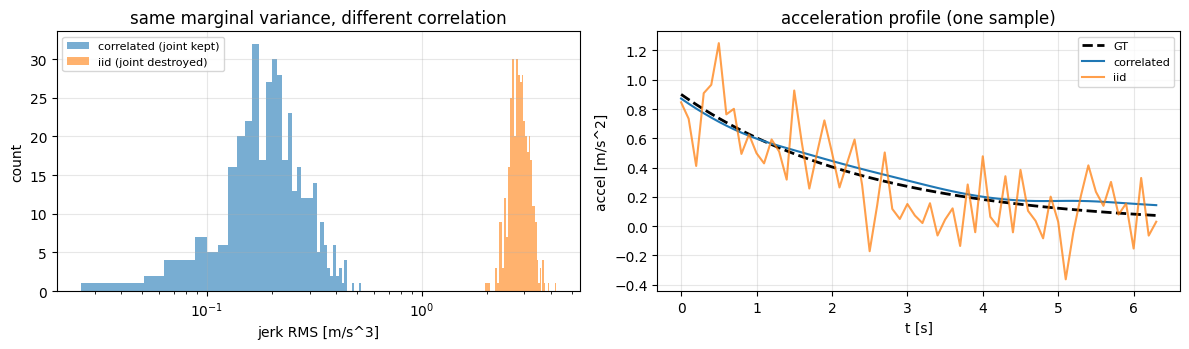

=> 周辺分散が厳密に同一でも、waypoint 間の相関を壊すだけで jerk が桁で悪化する。
   自己回帰デコードは各点を逐次独立にサンプルするため、後者の状態に陥りやすい。
   これが論文 Table 12 の Comfort 44% vs 97% の背後にあるメカニズムである。


In [17]:
print("【測定 3】 周辺分散を厳密に揃え、相関構造だけを変えた対照実験\n")

SIGMA = 0.30            # 正規化 action 空間での摂動の大きさ (両条件で共通)
B = Ate.shape[0]

# --- 相関なし: 各 waypoint 独立の白色ノイズ
pert_iid = torch.randn(B, N_WAYPOINTS, 2) * SIGMA

# --- 相関あり: 低周波基底 (cos) の線形結合。各点の周辺分散が SIGMA^2 になるよう正規化
n_basis = 4
tt = torch.arange(N_WAYPOINTS).float() / N_WAYPOINTS
basis = torch.stack([torch.cos(math.pi * k * tt) for k in range(n_basis)], dim=0)  # (n_basis, N)
coef = torch.randn(B, 2, n_basis)
pert_smooth = torch.einsum("bck,kn->bnc", coef, basis)
# 各 waypoint での標準偏差を SIGMA に厳密に合わせる
pert_smooth = pert_smooth / pert_smooth.std(dim=0, keepdim=True).clamp(min=1e-8) * SIGMA

a_iid = Ate + pert_iid
a_smooth = Ate + pert_smooth

# 周辺分散が本当に一致しているか (これが揃っていないと比較が成立しない)
sd_iid = (a_iid - Ate).std(dim=0).mean().item()
sd_smooth = (a_smooth - Ate).std(dim=0).mean().item()
print(f"waypoint ごとの摂動 std : iid={sd_iid:.4f}  smooth={sd_smooth:.4f}  "
      f"(差 {abs(sd_iid-sd_smooth):.5f})")
assert abs(sd_iid - sd_smooth) < 0.02, "周辺分散が揃っていないので比較が成立しない"

j_iid, c_iid = comfort_metrics(a_iid, Vte)
j_smooth, c_smooth = comfort_metrics(a_smooth, Vte)

print(f"\n{'':40s} {'jerk RMS [m/s^3]':>18s} {'comfort (|a|<2)':>18s}")
print(f"{'GT (unperturbed)':40s} {jerk_gt.mean():18.3f} {comf_gt.mean():17.1%}")
print(f"{'correlated perturbation (joint kept)':40s} {j_smooth.mean():18.3f} {c_smooth.mean():17.1%}")
print(f"{'iid perturbation (joint destroyed)':40s} {j_iid.mean():18.3f} {c_iid.mean():17.1%}")
print(f"\njerk の悪化倍率: {j_iid.mean()/j_smooth.mean():.0f}x  (周辺分散は同一)")
print(f"""
注意: comfort (|a|<2 の割合) は 2 群でほぼ同じ ({c_smooth.mean():.1%} vs {c_iid.mean():.1%}) である。
これは偶然ではなく必然で、この指標は各時刻の加速度の「周辺分布」しか見ていないため、
周辺分布を揃えた本実験では原理的に差が出ない。
系列としての性質を測るには jerk のように隣接点の差を見る指標が要る。
指標の選択を誤ると「自己回帰デコードでも問題ない」という誤った結論に到達しうる。
""")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(j_smooth.numpy(), bins=40, alpha=.6, label="correlated (joint kept)")
axes[0].hist(j_iid.numpy(), bins=40, alpha=.6, label="iid (joint destroyed)")
axes[0].set_xlabel("jerk RMS [m/s^3]"); axes[0].set_ylabel("count")
axes[0].set_xscale("log"); axes[0].legend(fontsize=8); axes[0].grid(alpha=.3)
axes[0].set_title("same marginal variance, different correlation")
i = 0
axes[1].plot(t_grid, Ate[i, :, 0] * ACCEL_STD + ACCEL_MEAN, "k--", lw=2, label="GT")
axes[1].plot(t_grid, a_smooth[i, :, 0] * ACCEL_STD + ACCEL_MEAN, label="correlated")
axes[1].plot(t_grid, a_iid[i, :, 0] * ACCEL_STD + ACCEL_MEAN, alpha=.75, label="iid")
axes[1].set_xlabel("t [s]"); axes[1].set_ylabel("accel [m/s^2]")
axes[1].legend(fontsize=8); axes[1].grid(alpha=.3)
axes[1].set_title("acceleration profile (one sample)")
plt.tight_layout()
plt.show()

assert j_iid.mean() > j_smooth.mean() * 3, (
    f"相関を壊した方が明確に jerk が大きいはず: iid={j_iid.mean():.3f} smooth={j_smooth.mean():.3f}")
assert abs(c_iid.mean() - c_smooth.mean()) < 0.05, (
    "周辺分布を揃えた以上、周辺分布のみを見る comfort 指標には差が出ないはず")
print("=> 周辺分散が厳密に同一でも、waypoint 間の相関を壊すだけで jerk が桁で悪化する。")
print("   自己回帰デコードは各点を逐次独立にサンプルするため、後者の状態に陥りやすい。")
print("   これが論文 Table 12 の Comfort 44% vs 97% の背後にあるメカニズムである。")


## 10. Reasoning-Action Consistency 報酬を実装する

論文 Sec.5.3.2 の $r_{\text{consistency}}$ は、**予測 trajectory を meta-action に変換して、
reasoning が主張する意図と照合する二値報酬**である。CoC の decision が閉集合だからこそ機械的に判定できる。

論文 Table 9 の要点は「reasoning 品質だけを最適化すると consistency は 0.62 → 0.53 に**悪化**する」だった。
ここでは報酬関数そのものを実装し、学習済みモデルの consistency を測る。


復元ルールの健全性 (GT action -> GT decision を再現できるか):
  longitudinal: 0.948
  lateral     : 0.909
  -> ルール自体は妥当。以降の consistency はモデル側の性質を測っている。



reasoning-action consistency (学習済み mini-Alpamayo) : 0.526
  参考: 論文 Table 9  SFT のみ = 0.62 / +r_consistency = 0.85

trajectory をシャッフルした場合                        : 0.154
  -> 「流暢な説明」だけでは報酬が取れない。行動と結びついて初めて上がる。

lateral decision ごとの consistency:
  Lane keeping & centering       n=142  consistency=0.310
  Lane change (lateral push)     n= 99  consistency=0.394
  Turn (intersection)            n=143  consistency=0.832


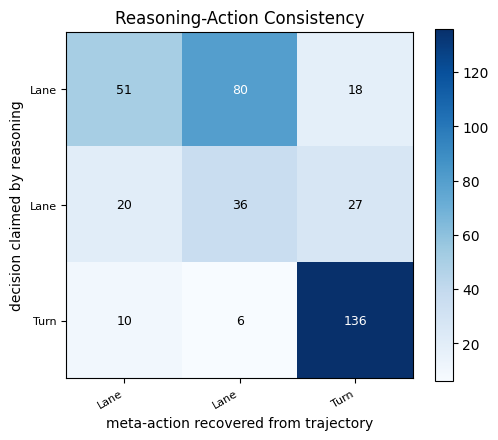


学習済み 0.526 vs シャッフル 0.154 => 報酬関数として機能している


In [18]:
TURN_YAW_THRESHOLD_RAD = 0.35    # これを超えるヨー変化は交差点旋回
LANE_CHANGE_LATERAL_M = 1.5      # 最終ヨーが戻っていて横に これ以上ずれたらレーンチェンジ


def trajectory_to_meta_action(act, v0):
    """予測 action からルールベースで CoC decision を復元する (論文 Table 5 の meta-action 相当).

    生の accel/kappa の閾値ではなく、積分した軌道の物理量 (最終ヨー・最終横位置・最低速度) で
    判定する。予測に高周波ノイズが乗っていても判定が揺れないようにするため。
    """
    xy, vel, theta = action_space.action_to_traj(act, v0)
    accel = act[..., 0] * ACCEL_STD + ACCEL_MEAN

    # --- longitudinal: 停止したか / 減速したか
    mean_a = accel.mean(-1)
    min_v = vel.min(-1).values
    lon = torch.zeros_like(mean_a, dtype=torch.long)                # Set speed tracking
    lon = torch.where(mean_a < -0.3, torch.ones_like(lon), lon)     # Lead obstacle following
    lon = torch.where(min_v < 0.6, torch.full_like(lon, 2), lon)    # Stop for static constraints

    # --- lateral: 最終ヨーが残っていれば旋回、戻っていて横ずれが大きければレーンチェンジ
    final_yaw = theta[..., -1].abs()
    final_lat = xy[..., -1, 1].abs()
    lat = torch.zeros_like(lon)                                                        # Lane keeping
    lat = torch.where(final_lat > LANE_CHANGE_LATERAL_M, torch.ones_like(lat), lat)    # Lane change
    lat = torch.where(final_yaw > TURN_YAW_THRESHOLD_RAD, torch.full_like(lat, 2), lat)  # Turn
    return lon, lat


# GT action に対して復元ルールが正しく効くかを先に検証する (ルール自体の健全性チェック)
lon_gt_rec, lat_gt_rec = trajectory_to_meta_action(Ate, Vte)
lon_rule_acc = (lon_gt_rec == LONte).float().mean().item()
lat_rule_acc = (lat_gt_rec == LATte).float().mean().item()
print(f"復元ルールの健全性 (GT action -> GT decision を再現できるか):")
print(f"  longitudinal: {lon_rule_acc:.3f}")
print(f"  lateral     : {lat_rule_acc:.3f}")
assert lon_rule_acc > 0.9 and lat_rule_acc > 0.9, (
    "meta-action 復元ルールが GT すら再現できていない。閾値設計が誤っている")
print("  -> ルール自体は妥当。以降の consistency はモデル側の性質を測っている。\n")


def consistency_reward(pred_act, v0, lon_logits, lat_logits):
    """r_consistency: 予測 trajectory 由来の meta-action と reasoning の decision が一致すれば 1."""
    lon_traj, lat_traj = trajectory_to_meta_action(pred_act, v0)
    lon_reason = lon_logits.argmax(-1)
    lat_reason = lat_logits.argmax(-1)
    return ((lon_traj == lon_reason) & (lat_traj == lat_reason)).float()


pred1, lon_lg, lat_lg = predict(Xte, Vte, num_samples=1)
pred1 = pred1[:, 0]

r_cons = consistency_reward(pred1, Vte, lon_lg, lat_lg)
lon_traj, lat_traj = trajectory_to_meta_action(pred1, Vte)

print(f"reasoning-action consistency (学習済み mini-Alpamayo) : {r_cons.mean():.3f}")
print(f"  参考: 論文 Table 9  SFT のみ = 0.62 / +r_consistency = 0.85")

# 対照実験: reasoning だけ正しく、trajectory をランダムに置き換えたら consistency はどうなるか
shuffled = pred1[torch.randperm(len(pred1))]
r_shuf = consistency_reward(shuffled, Vte, lon_lg, lat_lg)
print(f"\ntrajectory をシャッフルした場合                        : {r_shuf.mean():.3f}")
print("  -> 「流暢な説明」だけでは報酬が取れない。行動と結びついて初めて上がる。")

# decision ごとの内訳
print("\nlateral decision ごとの consistency:")
for i, name in enumerate(LAT_DECISIONS):
    m = (LATte == i)
    if m.sum() > 0:
        print(f"  {name:30s} n={int(m.sum()):3d}  consistency={r_cons[m].mean():.3f}")

# 混同行列: reasoning の decision vs trajectory から復元した meta-action
cm = np.zeros((len(LAT_DECISIONS), len(LAT_DECISIONS)), dtype=int)
for a, b in zip(lat_lg.argmax(-1).tolist(), lat_traj.tolist()):
    cm[a, b] += 1
fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(LAT_DECISIONS))); ax.set_yticks(range(len(LAT_DECISIONS)))
ax.set_xticklabels([n.split(" ")[0] for n in LAT_DECISIONS], rotation=30, ha="right", fontsize=8)
ax.set_yticklabels([n.split(" ")[0] for n in LAT_DECISIONS], fontsize=8)
ax.set_xlabel("meta-action recovered from trajectory"); ax.set_ylabel("decision claimed by reasoning")
ax.set_title("Reasoning-Action Consistency")
for i in range(len(LAT_DECISIONS)):
    for j in range(len(LAT_DECISIONS)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() * .5 else "black", fontsize=9)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

assert r_cons.mean() > r_shuf.mean() + 0.2, "consistency 報酬が行動と推論の結びつきを捉えていない"
print(f"\n学習済み {r_cons.mean():.3f} vs シャッフル {r_shuf.mean():.3f} => 報酬関数として機能している")


## 11. 推論ステップ数と精度のトレードオフ

論文 Table 12 は $\delta_t=0.2$（5 ステップ）でも劣化は無視できると述べている。
デフォルトの 10 ステップから減らしたときに minADE がどう動くかを測る。


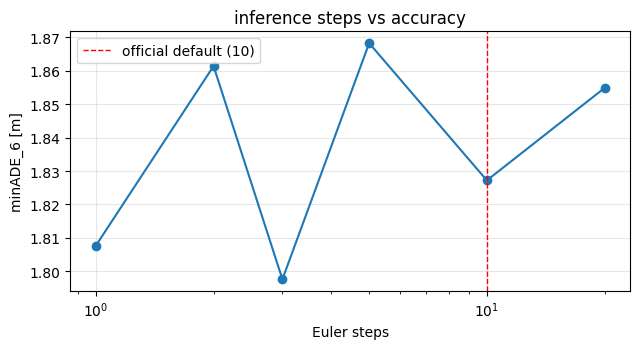

steps=  1  minADE_6 = 1.8077 m   (10 ステップ比 -1.1%)
steps=  2  minADE_6 = 1.8614 m   (10 ステップ比 +1.9%)
steps=  3  minADE_6 = 1.7976 m   (10 ステップ比 -1.6%)
steps=  5  minADE_6 = 1.8682 m   (10 ステップ比 +2.2%)
steps= 10  minADE_6 = 1.8272 m   (10 ステップ比 +0.0%)
steps= 20  minADE_6 = 1.8548 m   (10 ステップ比 +1.5%)

5 ステップでの劣化: +2.2%  (論文: 「無視できる程度」)
1 ステップでの劣化: -1.1%

[注意] このモデルでは 1 ステップですら 10 ステップと同等である。論文の設定とは異なる。
  9.1 節で見たとおり、この expert が学習したベクトル場は条件付き平均へまっすぐ向かうだけの
  ほぼ線形な場に退化しており、Euler 1 ステップでその平均に着いてしまう。

  実物で複数ステップが要るのは行動分布が本質的に多峰だからである
  (交差点で「止まる / 先に行く」など、平均を取るとどちらでもない軌道になる場面)。
  逆に言えば、ステップ数の ablation は
  「expert が多峰性を捉えているか」を診断する道具としても使える。


In [19]:
step_counts = [1, 2, 3, 5, 10, 20]
results = []
for s in step_counts:
    pa, _, _ = predict(Xte, Vte, num_samples=6, inference_step=s)
    results.append(min_ade(pa, Ate, Vte).mean().item())

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(step_counts, results, marker="o")
ax.axvline(NUM_INFERENCE_STEPS, color="r", ls="--", lw=1, label="official default (10)")
ax.set_xlabel("Euler steps"); ax.set_ylabel("minADE_6 [m]")
ax.set_xscale("log"); ax.legend(); ax.grid(alpha=.3)
ax.set_title("inference steps vs accuracy")
plt.tight_layout()
plt.show()

base = results[step_counts.index(10)]
for s, r in zip(step_counts, results):
    print(f"steps={s:3d}  minADE_6 = {r:.4f} m   (10 ステップ比 {(r/base - 1)*100:+.1f}%)")

deg5 = results[step_counts.index(5)] / base - 1
deg1 = results[step_counts.index(1)] / base - 1
print(f"\n5 ステップでの劣化: {deg5*100:+.1f}%  (論文: 「無視できる程度」)")
print(f"1 ステップでの劣化: {deg1*100:+.1f}%")

if abs(deg1) < 0.05:
    print(f"""
[注意] このモデルでは 1 ステップですら 10 ステップと同等である。論文の設定とは異なる。
  9.1 節で見たとおり、この expert が学習したベクトル場は条件付き平均へまっすぐ向かうだけの
  ほぼ線形な場に退化しており、Euler 1 ステップでその平均に着いてしまう。

  実物で複数ステップが要るのは行動分布が本質的に多峰だからである
  (交差点で「止まる / 先に行く」など、平均を取るとどちらでもない軌道になる場面)。
  逆に言えば、ステップ数の ablation は
  「expert が多峰性を捉えているか」を診断する道具としても使える。""")


## Takeaways

1. **Alpamayo は trajectory を回帰しない。** 加速度と曲率の系列を予測し、unicycle 運動学で積分する。
   これにより物理的にありえない経路が構造的に排除される。積分式は台形則で、公式実装は cumsum 2 本で書かれている。

2. **逆変換（trajectory → action）が本当の難所。** $\kappa=\Delta\theta/s$ は $v\to0$ で発散し、
   実験では境界値 0.33 の 1000 倍を超える値が出た。公式実装の 0.6 m/s クランプと bounds クランプは
   「あれば良い」ではなく**無いと学習が壊れる**種類の処理である。

3. **flow matching の実装は驚くほど単純。** $\boldsymbol{a}_t=t\boldsymbol{a}+(1-t)\boldsymbol{\epsilon}$、
   ターゲットは $\boldsymbol{a}-\boldsymbol{\epsilon}$、推論は Euler 積分の 10 行。
   ノイズスケジュール設計が不要な点が diffusion に対する実装上の優位である。

4. **timestep サンプラは意図的に偏らせてある。** `Beta(1.5, 1.0)` を反転させることで
   $t$ が 0 側（ノイズが多く生成が難しい領域）に寄る。uniform との差は本 notebook で可視化した。

5. **64 waypoint を同時に生成することが乗り心地を決める。** ただし本 notebook の toy expert は
   これを再現できなかった。出力に初期ノイズがほぼそのまま残っており（正規化空間で $\sigma\approx1$）、
   積分ステップを 10 倍にしても改善しないことから、原因は積分誤差ではなく expert の学習不足である。
   実物の action expert は 2.3B パラメータで、本 notebook のものは 6 桁小さい。
   そこでメカニズム自体は、周辺分散を厳密に揃えて相関構造だけを変えた対照実験で確認した
   —— 相関を壊すと jerk が桁で悪化する。**再現できなかったことを再現できたことにしないのが重要である。**

8. **指標の選び方を誤ると逆の結論に至る。** 周辺分布を揃えた対照実験では、
   comfort（$|a|<2$ の割合）に差は出ない。この指標は各時刻の周辺分布しか見ていないからである。
   系列としての品質を測るには jerk のように隣接点の差を見る指標が要る。

6. **Reasoning-Action Consistency は閉集合語彙があって初めて実装できる。**
   予測 trajectory からルールベースで meta-action を復元し、reasoning の decision と照合する二値報酬。
   trajectory をシャッフルすると報酬が落ちることを確認した ——
   「流暢な説明」ではなく「行動と結びついた説明」だけが報酬を得る設計になっている。

7. **expert は VLM を再実行しない。** prefill 済みの hidden states（実物では `past_key_values`）に
   attend するだけなので、10 ステップの拡散を回しても VLM の計算は 1 回で済む。
   これが 8.75 ms でのデコードを可能にしている。

実 VLM（`Qwen/Qwen3-VL-2B-Instruct`、Alpamayo 2 Super と同じ `qwen3_vl` 系統）を実 GPU に載せて
同じパイプラインを回した版は [alpamayo2_gpu_smoke_kaggle.ipynb](alpamayo2_gpu_smoke_kaggle.ipynb) にある。
理論の全体像は [alpamayo2.md](alpamayo2.md) を参照。
